In [91]:
# Extract register tokens from all validation cases
import numpy as np
from pathlib import Path

results_dir = Path("/nfs/data/nii/data1/Analysis/camaret___in_context_segmentation/ANALYSIS_20251122/results/checkpoints/2026-02-24_pious-leaf-117_register_tokens")
case_dirs = sorted([d for d in results_dir.iterdir() if d.is_dir()])
print(f"Found {len(case_dirs)} cases")

Found 192 cases


In [92]:
# Load register tokens and metadata for all cases

register_tokens = {}  # case_name -> (R, D)
case_names = []
labels = []
dices = []
axes_list = []

# Debug: check what files exist in first case dir
if case_dirs:
    sample_files = sorted([f.name for f in case_dirs[0].iterdir()])
    print(f"Files in first case dir: {sample_files}")

# Find register token files (any level)
reg_pattern = None
for case_dir in case_dirs[:5]:
    for f in case_dir.iterdir():
        if 'register_tokens' in f.name and f.suffix == '.npy':
            reg_pattern = f.name
            break
    if reg_pattern:
        break

if reg_pattern:
    print(f"Found register token file pattern: {reg_pattern}")
else:
    print("WARNING: No register token files found!")
    print("The backbone may not output register_tokens.")
    print("Proceeding with metadata only...")

# Load data
for case_dir in case_dirs:
    case_name = case_dir.name
    meta_file = case_dir / "metadata.npz"
    
    # Try to load register tokens
    if reg_pattern:
        reg_file = case_dir / reg_pattern
        if reg_file.exists():
            register_tokens[case_name] = np.load(reg_file)
    
    # Load metadata (always try)
    if meta_file.exists():
        meta = np.load(meta_file, allow_pickle=True)
        case_names.append(case_name)
        labels.append(str(meta["label_id"]))
        dices.append(float(meta["dice"]))
        axes_list.append(str(meta["axis"]))
    else:
        # Fallback: parse from case_name
        parts = case_name.split('_')
        case_names.append(case_name)
        labels.append('_'.join(parts[1:-1]))
        dices.append(np.nan)
        axes_list.append(parts[-1] if parts else "unk")

print(f"\nLoaded metadata for {len(case_names)} cases")
print(f"Loaded register tokens for {len(register_tokens)} cases")
if register_tokens:
    print(f"Register shape: {next(iter(register_tokens.values())).shape}")
print(f"Unique labels: {len(set(labels))}")
print(f"Dice scores available: {sum(~np.isnan(dices))}/{len(dices)}")

Files in first case dir: ['level0_layer0_attn_weights.npy', 'level0_layer1_attn_weights.npy', 'level0_patch_mask_pct.npy', 'level0_register_tokens.npy', 'level1_layer0_attn_weights.npy', 'level1_layer1_attn_weights.npy', 'level1_patch_mask_pct.npy', 'level1_register_tokens.npy', 'metadata.npz']
Found register token file pattern: level0_register_tokens.npy

Loaded metadata for 192 cases
Loaded register tokens for 192 cases
Register shape: (4, 256)
Unique labels: 42
Dice scores available: 192/192


In [93]:
# Stack into arrays for analysis
all_tokens = np.stack([register_tokens[name] for name in case_names], axis=0)  # (N, R, D)
labels_array = np.array(labels)
dices_array = np.array(dices)
unique_labels = sorted(set(labels))

print(f"All tokens shape: {all_tokens.shape}")
print(f"Labels: {unique_labels[:10]}...")  # Show first 10
print(f"Dice range: [{np.nanmin(dices_array):.3f}, {np.nanmax(dices_array):.3f}], mean={np.nanmean(dices_array):.3f}")

All tokens shape: (192, 4, 256)
Labels: ['atrial_appendage_left', 'autochthon_left', 'autochthon_right', 'brachiocephalic_trunk', 'brachiocephalic_vein_left', 'brachiocephalic_vein_right', 'colon', 'costal_cartilages', 'esophagus', 'iliac_artery_left']...
Dice range: [0.000, 0.622], mean=0.099


In [94]:
# Basic statistics per register token
print("=== Register Token Statistics ===\n")

n_registers = all_tokens.shape[1]
for reg_idx in range(n_registers):
    reg_tokens = all_tokens[:, reg_idx, :]  # (N, D)
    mean_norm = np.linalg.norm(reg_tokens, axis=1).mean()
    std_norm = np.linalg.norm(reg_tokens, axis=1).std()
    
    # Variance across cases (how much does this register vary?)
    variance = reg_tokens.var(axis=0).mean()
    
    print(f"Register {reg_idx}: norm={mean_norm:.2f}±{std_norm:.2f}, var={variance:.4f}")

=== Register Token Statistics ===

Register 0: norm=16.00±0.00, var=0.1934
Register 1: norm=16.00±0.00, var=0.1972
Register 2: norm=16.00±0.00, var=0.1976
Register 3: norm=16.00±0.00, var=0.1965


In [95]:
# Average register tokens per anatomical label
label_avg_tokens = {}  # label -> (8, 512)

for label in unique_labels:
    mask = labels_array == label
    label_tokens = all_tokens[mask]  # (n_cases, 8, 512)
    label_avg_tokens[label] = label_tokens.mean(axis=0)  # (8, 512)

print(f"Computed average tokens for {len(label_avg_tokens)} labels")
print(f"Sample labels: {list(label_avg_tokens.keys())[:5]}")

Computed average tokens for 42 labels
Sample labels: ['atrial_appendage_left', 'autochthon_left', 'autochthon_right', 'brachiocephalic_trunk', 'brachiocephalic_vein_left']


In [96]:
# Compute cosine similarity between label-averaged register tokens
from sklearn.metrics.pairwise import cosine_similarity

# Flatten registers for each label: (8, 512) -> (4096,)
label_vectors = np.stack([label_avg_tokens[l].flatten() for l in unique_labels])  # (n_labels, 4096)

# Cosine similarity matrix
sim_matrix = cosine_similarity(label_vectors)

print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Similarity range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")
print(f"Mean off-diagonal similarity: {(sim_matrix.sum() - np.trace(sim_matrix)) / (sim_matrix.size - len(unique_labels)):.3f}")

Similarity matrix shape: (42, 42)
Similarity range: [0.305, 1.000]
Mean off-diagonal similarity: 0.846


In [97]:
# Save extracted data
output_dir = Path(".")
np.savez(output_dir / "register_tokens_data.npz",
         all_tokens=all_tokens,
         case_names=case_names,
         labels=labels,
         unique_labels=unique_labels,
         dices=dices_array,
         axes=axes_list)

print(f"Saved to {output_dir / 'register_tokens_data.npz'}")

Saved to register_tokens_data.npz


In [98]:
# 2D projection per register token using UMAP
# Each register gets its own embedding, plotting individual cases (not averaged)
from umap import UMAP
import matplotlib.pyplot as plt

# Compute UMAP embedding for each register separately
embeddings = {}  # reg_idx -> (N, 2)
n_registers = all_tokens.shape[1]

for reg_idx in range(n_registers):
    reg_tokens = all_tokens[:, reg_idx, :]  # (N, D) - one token per case
    reducer = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    embeddings[reg_idx] = reducer.fit_transform(reg_tokens)
    print(f"Register {reg_idx}: embedded {reg_tokens.shape} -> {embeddings[reg_idx].shape}")

/software/anaconda3/envs/segfm3d_2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Register 0: embedded (192, 256) -> (192, 2)


/software/anaconda3/envs/segfm3d_2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Register 1: embedded (192, 256) -> (192, 2)


/software/anaconda3/envs/segfm3d_2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Register 2: embedded (192, 256) -> (192, 2)


/software/anaconda3/envs/segfm3d_2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Register 3: embedded (192, 256) -> (192, 2)


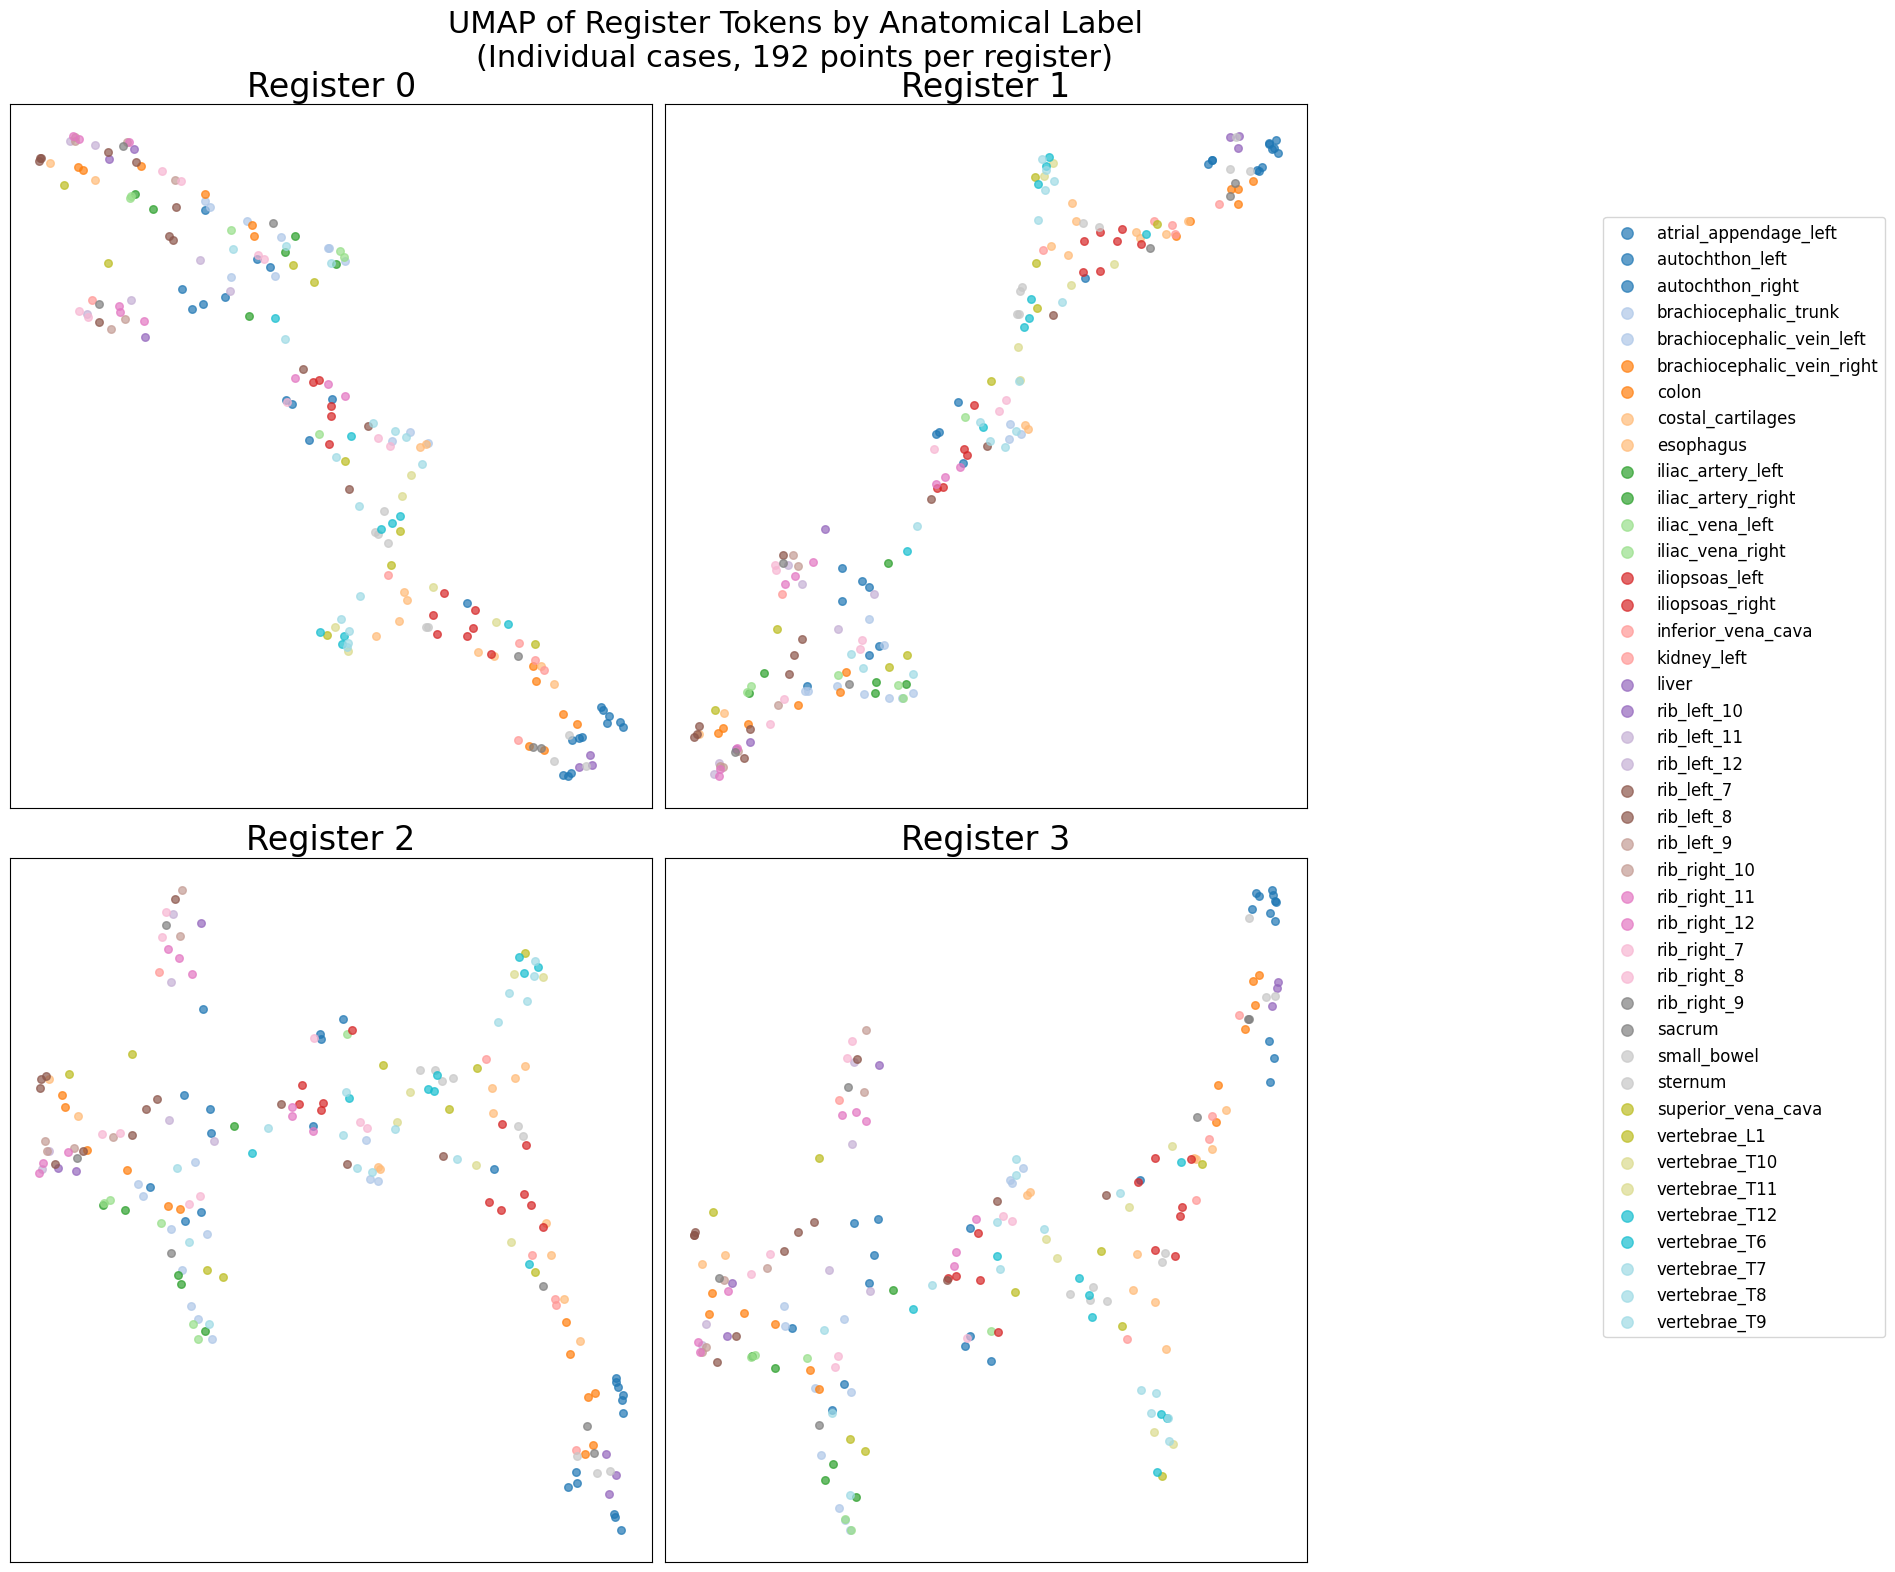

In [99]:
# Plot embeddings for each register separately (individual cases, not averaged)
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

# Create color map for labels
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = {label: colors[i] for i, label in enumerate(unique_labels)}

# Store handles for legend (from first plot)
legend_handles = []
legend_labels_list = []

n_plot = min(4, n_registers)
for reg_idx in range(n_plot):
    ax = axes[reg_idx]
    emb = embeddings[reg_idx]
    
    for label in unique_labels:
        mask = labels_array == label
        scatter = ax.scatter(emb[mask, 0], emb[mask, 1], 
                           c=[label_to_color[label]], s=30, alpha=0.7, label=label)
        if reg_idx == 0:  # Collect legend from first plot
            legend_handles.append(scatter)
            legend_labels_list.append(label)
    
    ax.set_title(f'Register {reg_idx}', fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused axes
for reg_idx in range(n_plot, 4):
    axes[reg_idx].axis('off')

plt.suptitle(f'UMAP of Register Tokens by Anatomical Label\n(Individual cases, {len(case_names)} points per register)', y=0.98, fontsize=22)

# Add legend to the right of the plot
fig.legend(legend_handles, legend_labels_list, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=12, markerscale=1.5, frameon=True, ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.82)  # Make room for legend
plt.show()

Categories found: ['Bones (Ribs/Sternum)', 'Bones (Spine)', 'Muscles', 'Organs (Abd/Pelvis)', 'Organs (Thorax/Head/Spine)', 'Vessels']
Category distribution:
  Bones (Ribs/Sternum): 60
  Bones (Spine): 36
  Muscles: 30
  Organs (Abd/Pelvis): 21
  Organs (Thorax/Head/Spine): 6
  Vessels: 39


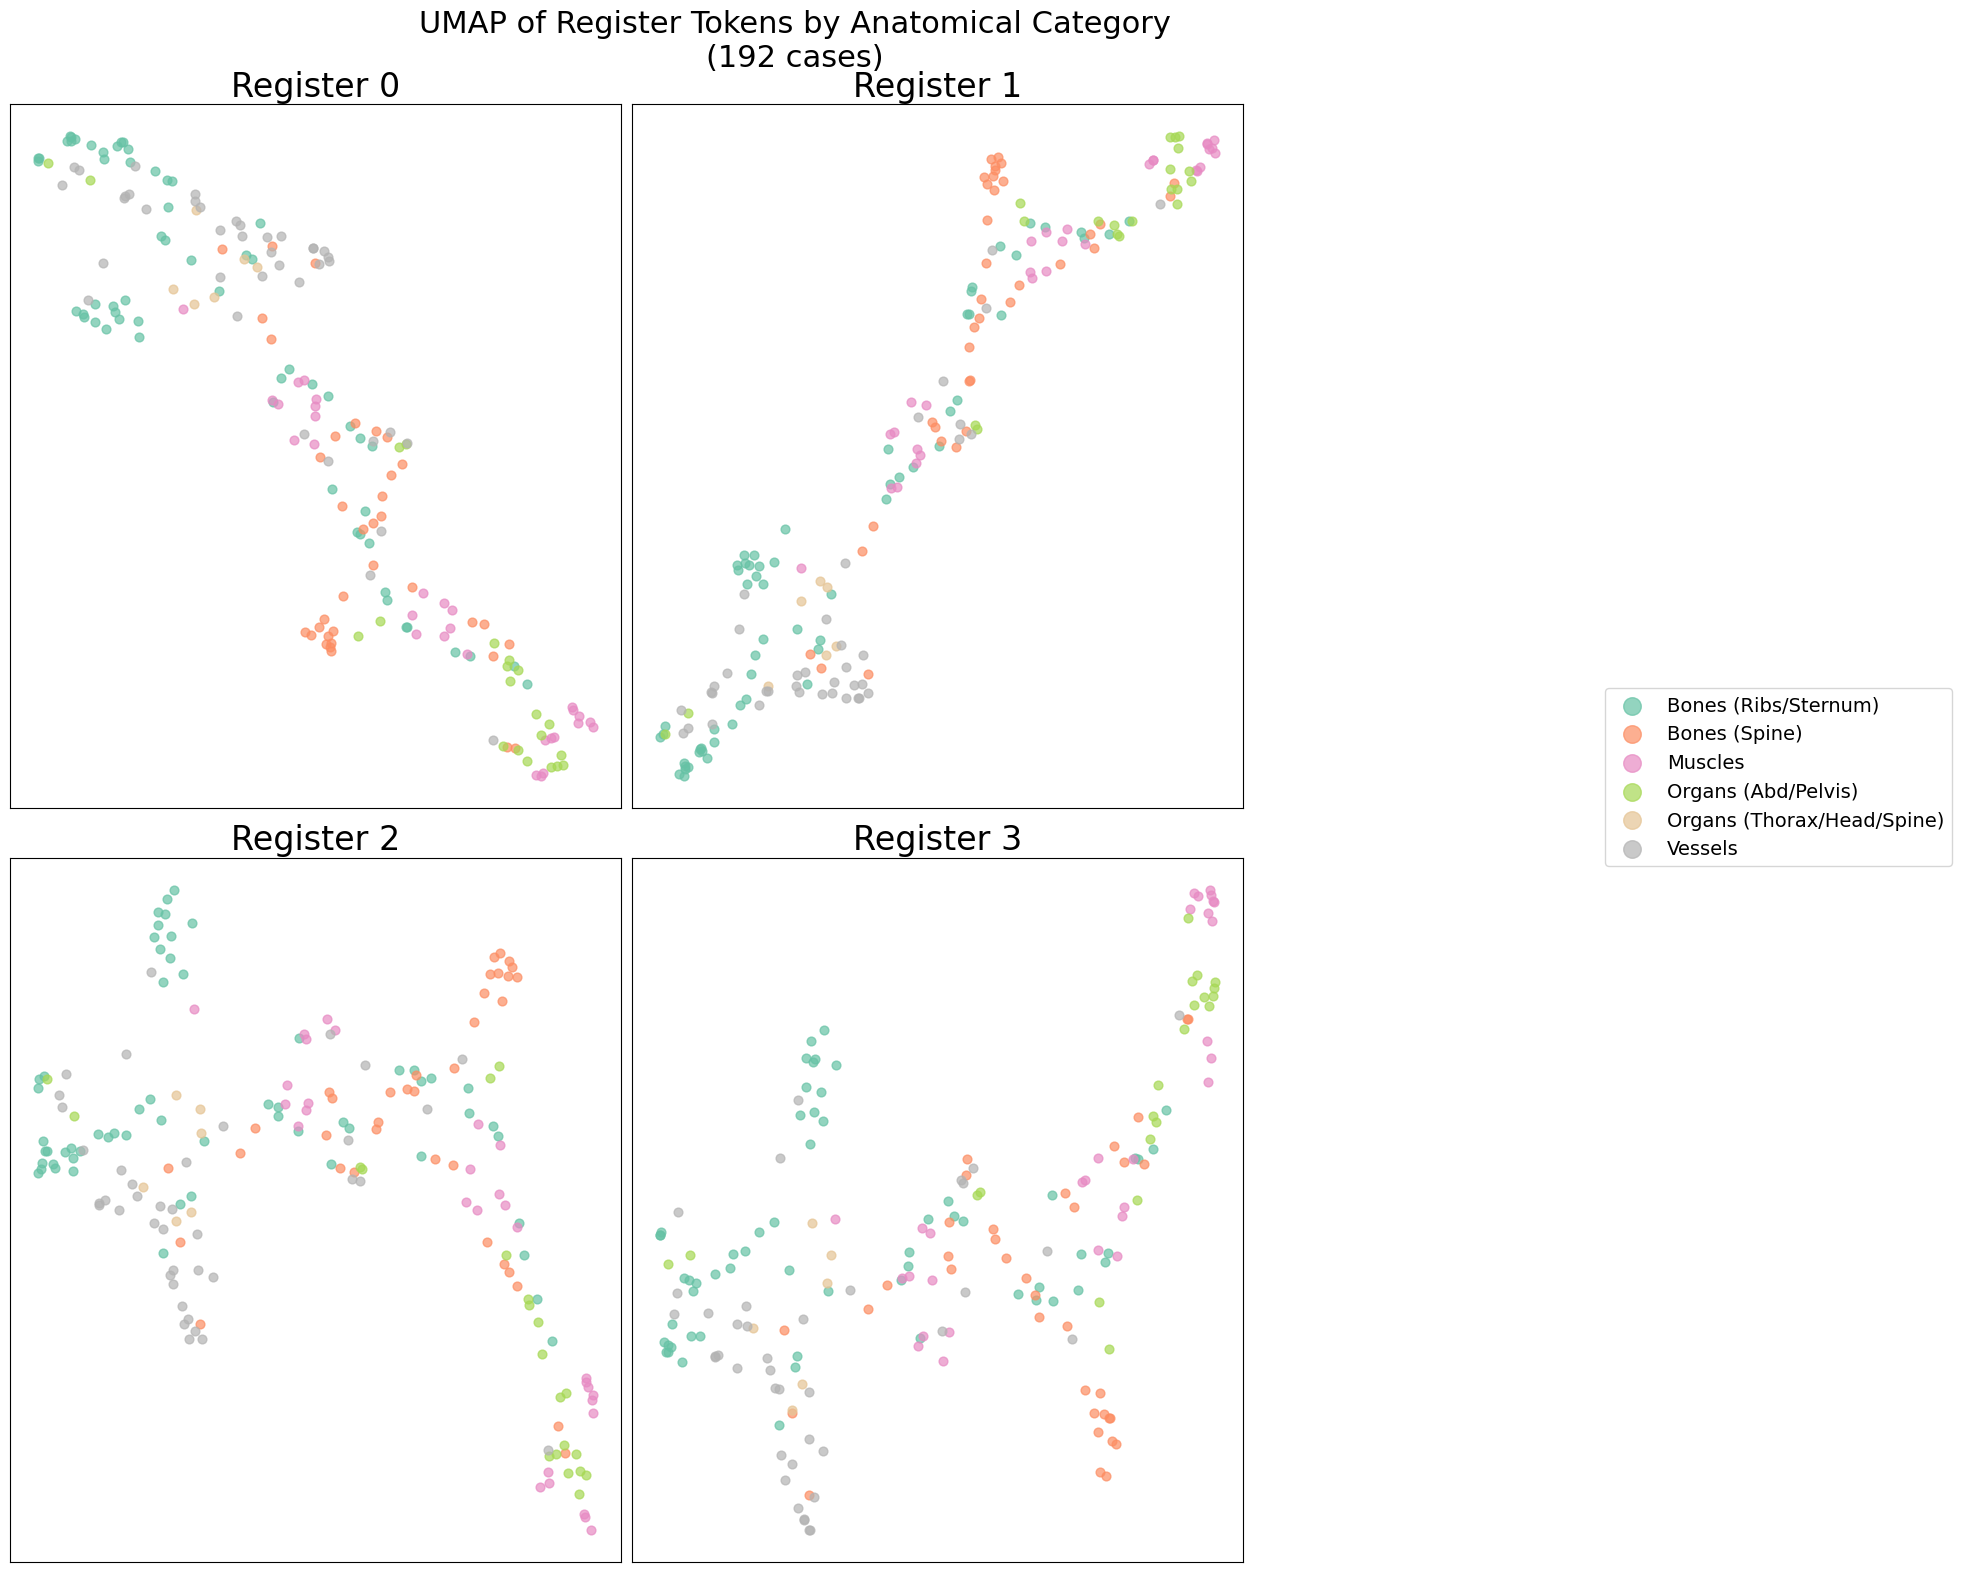

In [100]:
# Plot embeddings by anatomical CATEGORY (grouped labels)
import sys
sys.path.insert(0, str(Path("..").resolve()))
from data.label_ids_totalseg import category_map

# Map labels to categories
categories = [category_map.get(label, "Unknown") for label in labels]
categories_array = np.array(categories)
unique_categories = sorted(set(categories))

print(f"Categories found: {unique_categories}")
print(f"Category distribution:")
for cat in unique_categories:
    count = (categories_array == cat).sum()
    print(f"  {cat}: {count}")

# Create color map for categories (fewer colors needed)
cat_colors = plt.cm.Set2(np.linspace(0, 1, len(unique_categories)))
cat_to_color = {cat: cat_colors[i] for i, cat in enumerate(unique_categories)}

# Plot per-register UMAP colored by category
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

legend_handles = []
legend_labels_cat = []

n_plot = min(4, n_registers)
for reg_idx in range(n_plot):
    ax = axes[reg_idx]
    emb = embeddings[reg_idx]
    
    for cat in unique_categories:
        mask = categories_array == cat
        scatter = ax.scatter(emb[mask, 0], emb[mask, 1], 
                           c=[cat_to_color[cat]], s=40, alpha=0.7, label=cat)
        if reg_idx == 0:
            legend_handles.append(scatter)
            legend_labels_cat.append(cat)
    
    ax.set_title(f'Register {reg_idx}', fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])

for reg_idx in range(n_plot, 4):
    axes[reg_idx].axis('off')

plt.suptitle(f'UMAP of Register Tokens by Anatomical Category\n({len(case_names)} cases)', y=0.98, fontsize=22)

fig.legend(legend_handles, legend_labels_cat, loc='center left', bbox_to_anchor=(1.0, 0.5), 
           fontsize=14, markerscale=2, frameon=True, ncol=1)

plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

Combined embedding: 768 points (192 cases × 4 registers)


/software/anaconda3/envs/segfm3d_2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


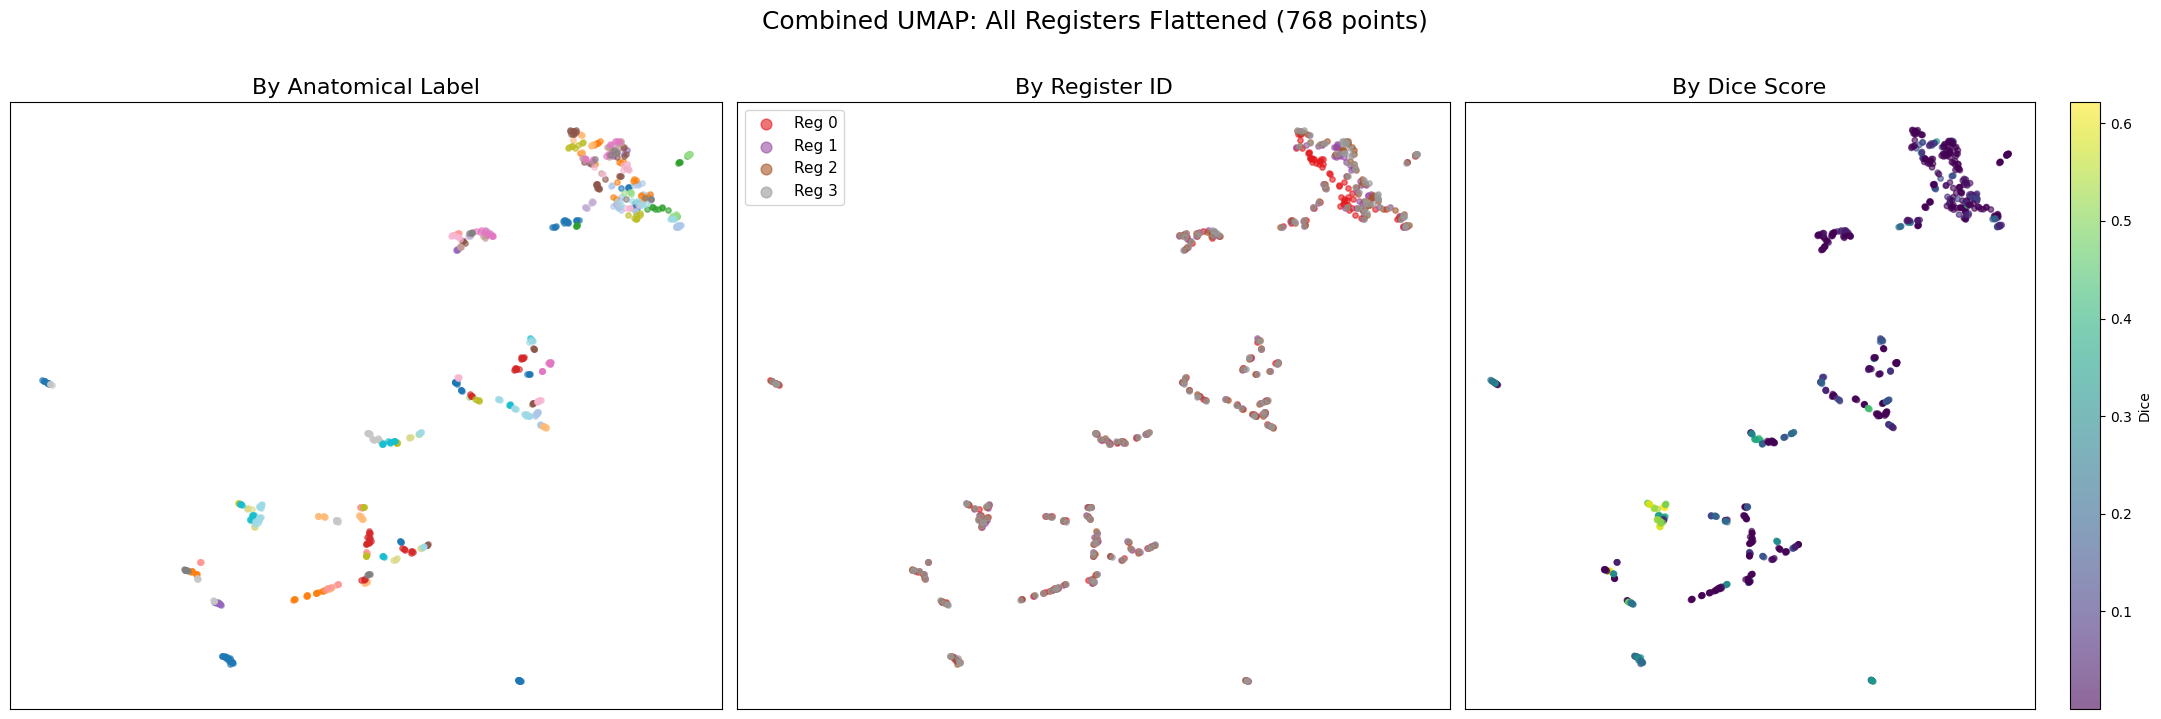

In [101]:
# Alternative: Combined UMAP of ALL register tokens (flattened)
# Each point = one register from one case

n_cases, n_regs, n_dims = all_tokens.shape
all_tokens_flat = all_tokens.reshape(-1, n_dims)  # (N*R, D)
labels_flat = np.repeat(labels_array, n_regs)
register_ids_flat = np.tile(np.arange(n_regs), n_cases)
dices_flat = np.repeat(dices_array, n_regs)

print(f"Combined embedding: {all_tokens_flat.shape[0]} points ({n_cases} cases × {n_regs} registers)")

reducer_combined = UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_combined = reducer_combined.fit_transform(all_tokens_flat)

# Plot side by side: by label, by register ID, by dice
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# By anatomical label
ax = axes[0]
for label in unique_labels:
    mask = labels_flat == label
    ax.scatter(embedding_combined[mask, 0], embedding_combined[mask, 1], 
               c=[label_to_color[label]], s=15, alpha=0.6, label=label)
ax.set_title('By Anatomical Label', fontsize=16)
ax.set_xticks([]); ax.set_yticks([])

# By register ID
ax = axes[1]
reg_colors = plt.cm.Set1(np.linspace(0, 1, n_regs))
for reg_idx in range(n_regs):
    mask = register_ids_flat == reg_idx
    ax.scatter(embedding_combined[mask, 0], embedding_combined[mask, 1], 
               c=[reg_colors[reg_idx]], s=15, alpha=0.6, label=f'Reg {reg_idx}')
ax.set_title('By Register ID', fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
ax.legend(fontsize=11, markerscale=2)

# By dice score
ax = axes[2]
sc = ax.scatter(embedding_combined[:, 0], embedding_combined[:, 1], 
                c=dices_flat, cmap='viridis', s=15, alpha=0.6)
ax.set_title('By Dice Score', fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(sc, ax=ax, label='Dice')

plt.suptitle(f'Combined UMAP: All Registers Flattened ({len(embedding_combined)} points)', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [102]:
# Load target mask sizes from saved results (if available)
# New format uses .npy, old format uses .nii.gz

mask_sizes = []
has_masks = False

for case_name in case_names:
    case_dir = results_dir / case_name
    
    # Try new format first (.npy), then old format (.nii.gz)
    npy_path = case_dir / 'gt_mask.npy'
    nii_path = case_dir / 'gt_mask.nii.gz'
    
    if npy_path.exists():
        gt_mask = np.load(npy_path)
        mask_sizes.append((gt_mask > 0).sum())
        has_masks = True
    elif nii_path.exists():
        import nibabel as nib
        gt_mask = nib.load(nii_path).get_fdata()
        mask_sizes.append((gt_mask > 0).sum())
        has_masks = True
    else:
        mask_sizes.append(np.nan)

mask_sizes = np.array(mask_sizes)

if has_masks:
    valid = ~np.isnan(mask_sizes)
    print(f"Mask sizes ({valid.sum()}/{len(mask_sizes)} available): "
          f"min={mask_sizes[valid].min():.0f}, max={mask_sizes[valid].max():.0f}, mean={mask_sizes[valid].mean():.0f}")
else:
    print("No mask files found. Run eval with logging.save_register_images=true to save masks.")

No mask files found. Run eval with logging.save_register_images=true to save masks.


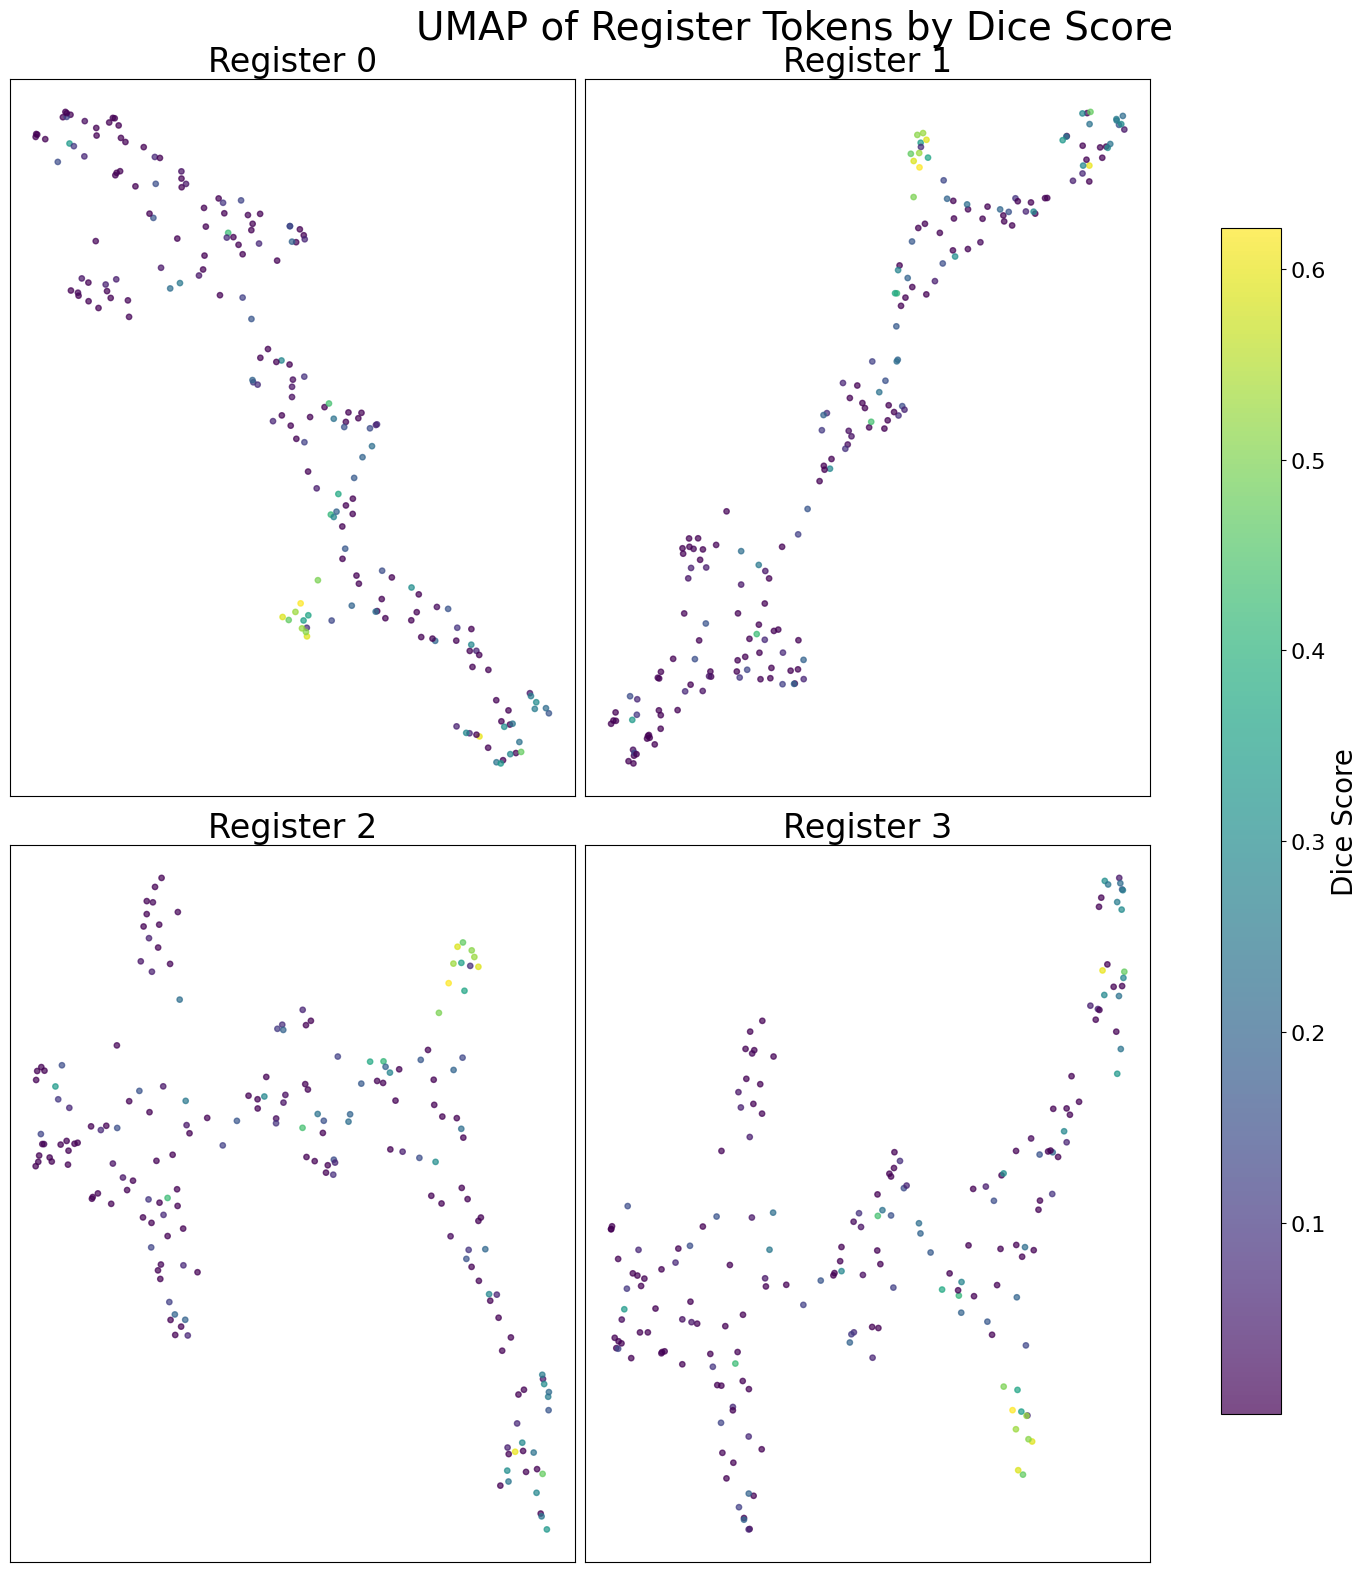

In [103]:
# Plot embeddings colored by mask_sizes or dice scores
# Use dice if masks not available

if has_masks and (~np.isnan(mask_sizes)).sum() > 0:
    color_values = np.log10(np.nan_to_num(mask_sizes, nan=1) + 1)
    color_label = 'Log10(mask_size + 1)'
    title_suffix = 'Mask Size (log scale)'
else:
    color_values = dices_array
    color_label = 'Dice Score'
    title_suffix = 'Dice Score'

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

n_plot = min(4, n_registers)
for reg_idx in range(n_plot):
    ax = axes[reg_idx]
    emb = embeddings[reg_idx]
    
    scatter = ax.scatter(emb[:, 0], emb[:, 1], 
                        c=color_values,
                        cmap='viridis', s=15, alpha=0.7)
    ax.set_title(f'Register {reg_idx}', fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f'UMAP of Register Tokens by {title_suffix}', y=0.98, fontsize=28)

plt.tight_layout()
plt.subplots_adjust(right=0.9)

cbar = fig.colorbar(scatter, ax=axes, label=color_label, shrink=0.8)
cbar.ax.tick_params(labelsize=16)
cbar.set_label(color_label, fontsize=20)

plt.show()

In [104]:
# Compute distance between target and context mask centroids (if masks available)
# This requires save_register_images=true during eval

from scipy.ndimage import center_of_mass

target_context_distances = []
has_context_masks = False

for case_name in case_names:
    case_dir = results_dir / case_name
    
    # Try to load target mask
    target_npy = case_dir / 'gt_mask.npy'
    target_nii = case_dir / 'gt_mask.nii.gz'
    context_nii = case_dir / 'context0_gt_mask.nii.gz'
    
    if target_npy.exists():
        target_mask = np.load(target_npy)
    elif target_nii.exists():
        target_mask = nib.load(target_nii).get_fdata()
    else:
        target_context_distances.append(np.nan)
        continue
    
    # Context masks only available in old format
    if context_nii.exists():
        context_mask = nib.load(context_nii).get_fdata()
        has_context_masks = True
        
        target_centroid = np.array(center_of_mass(target_mask))
        context_centroid = np.array(center_of_mass(context_mask))
        dist = np.linalg.norm(target_centroid - context_centroid)
        target_context_distances.append(dist)
    else:
        target_context_distances.append(np.nan)

target_context_distances = np.array(target_context_distances)

if has_context_masks:
    valid = ~np.isnan(target_context_distances)
    print(f"Target-context distance ({valid.sum()}/{len(target_context_distances)} available): "
          f"min={target_context_distances[valid].min():.1f}, "
          f"max={target_context_distances[valid].max():.1f}, "
          f"mean={target_context_distances[valid].mean():.1f}")
else:
    print("No context masks found. This metric requires the old output format with context masks.")

No context masks found. This metric requires the old output format with context masks.


In [105]:
# Plot embeddings colored by target-context distance (if available)

if has_context_masks and (~np.isnan(target_context_distances)).sum() > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()

    n_plot = min(4, n_registers)
    for reg_idx in range(n_plot):
        ax = axes[reg_idx]
        emb = embeddings[reg_idx]
        valid = ~np.isnan(target_context_distances)
        sc = ax.scatter(emb[valid, 0], emb[valid, 1], 
                       c=target_context_distances[valid], cmap='plasma', s=15, alpha=0.7)
        ax.set_title(f'Register {reg_idx}', fontsize=24)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle('UMAP of Register Tokens by Target-Context Distance', y=0.98, fontsize=28)

    plt.tight_layout()
    plt.subplots_adjust(right=0.9)

    cbar = fig.colorbar(sc, ax=axes, label='Centroid distance (pixels)', shrink=0.8)
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('Centroid distance (pixels)', fontsize=20)

    plt.show()
else:
    print("Skipping target-context distance plot (no context masks available)")

Skipping target-context distance plot (no context masks available)


Correlation between mask % and attention to zero_attn: -0.0138
Data points: 900


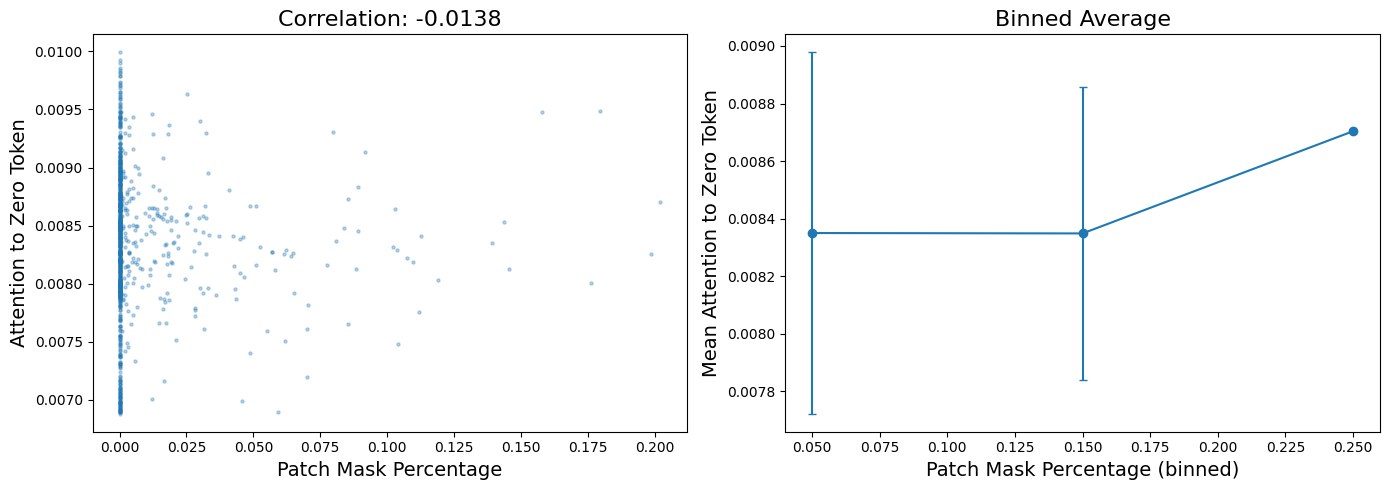

In [106]:
# Analyze correlation between patch mask percentage and attention to zero_attn
# The zero_attn token is the LAST column in attention weights

zero_attn_data = []  # (mask_pct, attn_to_zero) pairs

for case_name in case_names[:100]:  # Sample first 100 cases for speed
    case_dir = results_dir / case_name
    
    # Find attention weights and mask percentages
    for level in range(5):
        attn_file = case_dir / f"level{level}_layer0_attn_weights.npy"
        mask_pct_file = case_dir / f"level{level}_patch_mask_pct.npy"
        
        if attn_file.exists() and mask_pct_file.exists():
            attn = np.load(attn_file)  # [H, K, K+1] - last col is zero_attn
            mask_pct = np.load(mask_pct_file)  # [K]
            
            # Average attention to zero_attn across heads
            attn_to_zero = attn[:, :, -1].mean(axis=0)  # [K]
            
            for k in range(len(mask_pct)):
                zero_attn_data.append((mask_pct[k], attn_to_zero[k]))
            break  # Only use first level found

if zero_attn_data:
    zero_attn_data = np.array(zero_attn_data)
    mask_pcts = zero_attn_data[:, 0]
    attn_to_zero = zero_attn_data[:, 1]
    
    # Compute correlation
    corr = np.corrcoef(mask_pcts, attn_to_zero)[0, 1]
    print(f"Correlation between mask % and attention to zero_attn: {corr:.4f}")
    print(f"Data points: {len(zero_attn_data)}")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Scatter plot
    axes[0].scatter(mask_pcts, attn_to_zero, alpha=0.3, s=5)
    axes[0].set_xlabel('Patch Mask Percentage', fontsize=14)
    axes[0].set_ylabel('Attention to Zero Token', fontsize=14)
    axes[0].set_title(f'Correlation: {corr:.4f}', fontsize=16)
    
    # Binned average
    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_means = []
    bin_stds = []
    for i in range(len(bins) - 1):
        mask = (mask_pcts >= bins[i]) & (mask_pcts < bins[i+1])
        if mask.sum() > 0:
            bin_means.append(attn_to_zero[mask].mean())
            bin_stds.append(attn_to_zero[mask].std())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
    
    axes[1].errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', capsize=3)
    axes[1].set_xlabel('Patch Mask Percentage (binned)', fontsize=14)
    axes[1].set_ylabel('Mean Attention to Zero Token', fontsize=14)
    axes[1].set_title('Binned Average', fontsize=16)
    
    plt.tight_layout()
    plt.show()
else:
    print("No attention weight or mask percentage files found.")
    print("Run eval with logging.save_register_tokens=true first.")